In [50]:
import numpy as np
import sklearn as sk
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

import matplotlib.pyplot as plt

from utils import gen_data

## Generating Data

In [51]:
X, y = gen_data()

print(X[:5], '\n', y[:5])

[[142]
 [219]
 [132]
 [ 54]
 [146]] 
 [118587 218242 125672  13339 137882]


## Plotting Data

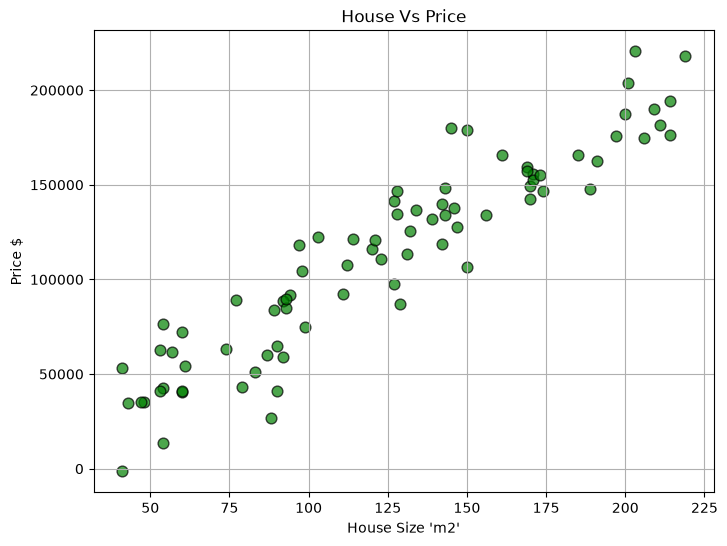

In [52]:
plt.figure(figsize=(8, 6))
plt.scatter(X, y, color='green', s=60, alpha=0.7, edgecolors='black')

plt.title('House Vs Price')

plt.xlabel("House Size 'm2'")
plt.ylabel("Price $")

plt.grid(True)

plt.show()

## Splting data

In [53]:
X_train, _x, y_train, _y = train_test_split(X, y, test_size=0.3, random_state=42)
X_cv, X_test, y_cv, y_test = train_test_split(_x, _y, test_size=0.3, random_state=41)
print(_x.shape)
print(X_train.shape, X_cv.shape, X_test.shape)

(24, 1)
(56, 1) (16, 1) (8, 1)


## Scaling Data

In [54]:
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(X_train)
x_cv_scaled = scaler.fit_transform(X_cv)
x_test_scaled = scaler.fit_transform(X_test)

print(x_train_scaled[:5])
print(x_cv_scaled[:5])
print(x_test_scaled[:5])

[[0.35183955]
 [0.27158287]
 [1.53562556]
 [0.41203206]
 [1.19453468]]
[[-0.23877938]
 [-1.21379516]
 [-0.97501578]
 [ 0.49745703]
 [ 0.23877938]]
[[-0.01317547]
 [-1.44666668]
 [ 1.18842746]
 [ 0.00790528]
 [ 0.21871281]]


In [55]:
model = Ridge(alpha=0.1)
model.fit(x_train_scaled, y_train)

,"alpha alpha: float or array-like of shape (n_targets,), default=1.0Constant that multiplies the L2 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Ridge` object is not advised.Instead, you should use the :class:`LinearRegression` object.If an array is passed, penalties are assumed to be specific to thetargets. Hence they must correspond in number.See :ref:`sphx_glr_auto_examples_linear_model_plot_ridge_coeffs.py`for an illustration of the effect of alpha on the model coefficients.",0.1
,"fit_intercept fit_intercept: bool, default=TrueWhether to fit the intercept for this model. If setto false, no intercept will be used in calculations(i.e. ``X`` and ``y`` are expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=NoneMaximum number of iterations for conjugate gradient solver.For 'sparse_cg' and 'lsqr' solvers, the default value is determinedby scipy.sparse.linalg. For 'sag' solver, the default value is 1000.For 'lbfgs' solver, the default value is 15000.",None
,"tol tol: float, default=1e-4The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for each solver:- 'svd': `tol` has no impact.- 'cholesky': `tol` has no impact.- 'sparse_cg': norm of residuals smaller than `tol`.- 'lsqr': `tol` is set as atol and btol of scipy.sparse.linalg.lsqr, which control the norm of the residual vector in terms of the norms of matrix and coefficients.- 'sag' and 'saga': relative change of coef smaller than `tol`.- 'lbfgs': maximum of the absolute (projected) gradient=max|residuals| smaller than `tol`... versionchanged:: 1.2 Default value changed from 1e-3 to 1e-4 for consistency with other linear models.",0.0001
,"solver solver: {'auto', 'svd', 'cholesky', 'lsqr', 'sparse_cg', 'sag', 'saga', 'lbfgs'}, default='auto'Solver to use in the computational routines:- 'auto' chooses the solver automatically based on the type of data.- 'svd' uses a Singular Value Decomposition of X to compute the Ridge coefficients. It is the most stable solver, in particular more stable for singular matrices than 'cholesky' at the cost of being slower.- 'cholesky' uses the standard :func:`scipy.linalg.solve` function to obtain a closed-form solution.- 'sparse_cg' uses the conjugate gradient solver as found in :func:`scipy.sparse.linalg.cg`. As an iterative algorithm, this solver is more appropriate than 'cholesky' for large-scale data (possibility to set `tol` and `max_iter`).- 'lsqr' uses the dedicated regularized least-squares routine :func:`scipy.sparse.linalg.lsqr`. It is the fastest and uses an iterative procedure.- 'sag' uses a Stochastic Average Gradient descent, and 'saga' uses its improved, unbiased version named SAGA. Both methods also use an iterative procedure, and are often faster than other solvers when both n_samples and n_features are large. Note that 'sag' and 'saga' fast convergence is only guaranteed on features with approximately the same scale. You can preprocess the data with a scaler from :mod:`sklearn.preprocessing`.- 'lbfgs' uses L-BFGS-B algorithm implemented in :func:`scipy.optimize.minimize`. It can be used only when `positive` is True.All solvers except 'svd' support both dense and sparse data. However, only'lsqr', 'sag', 'sparse_cg', and 'lbfgs' support sparse input when`fit_intercept` is True... versionadded:: 0.17 Stochastic Average Gradient descent solver... versionadded:: 0.19 SAGA solver.",'auto'
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.Only 'lbfgs' solver is supported in this case.",False
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag' or 'saga' 

In [56]:
mse_train = mean_squared_error(x_train_scaled, y_train)
print(mse_train)

16644002491.52931


In [57]:
yhat_cv = model.predict(x_cv_scaled)

In [58]:
mse_cv = mean_squared_error(x_cv_scaled, y_cv)
print(mse_cv)

11320380397.294174
